In [4]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.weightstats import ztest

# ==========================================
# 1. LOAD THE DATA
# ==========================================
# Load the CSV file shown in your screenshot
df = pd.read_csv("sms_spam.csv", encoding="latin-1")

# Create a simple numeric column to help us find outliers (length of the message)
df['length'] = df['text'].astype(str).apply(len)

In [5]:
# ==========================================
# 2. BEFORE PREPROCESSING
# ==========================================
print("----- BEFORE PREPROCESSING -----\n")
print("1. Shape:")
print(df.shape)

----- BEFORE PREPROCESSING -----

1. Shape:
(5574, 3)


In [6]:
print("\n2. Data Types:")
print(df.dtypes)


2. Data Types:
type      object
text      object
length     int64
dtype: object


In [7]:
print("\n3. Missing Values:")
print(df.isnull().sum())


3. Missing Values:
type      0
text      0
length    0
dtype: int64


In [8]:
print("\n4. Describe (Summary Statistics):")
print(df.describe())


4. Describe (Summary Statistics):
            length
count  5574.000000
mean     80.563689
std      59.907799
min       2.000000
25%      36.000000
50%      62.000000
75%     122.000000
max     910.000000


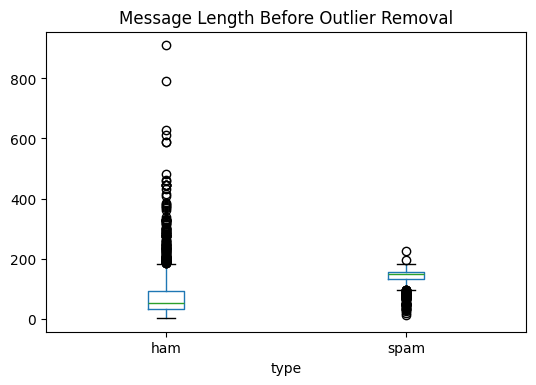

In [9]:
# --- Visualizations Before ---
# 1. Boxplot
df.boxplot(column='length', by='type', grid=False, figsize=(6,4))
plt.title("Message Length Before Outlier Removal")
plt.suptitle("") # Removes default pandas title
plt.show()

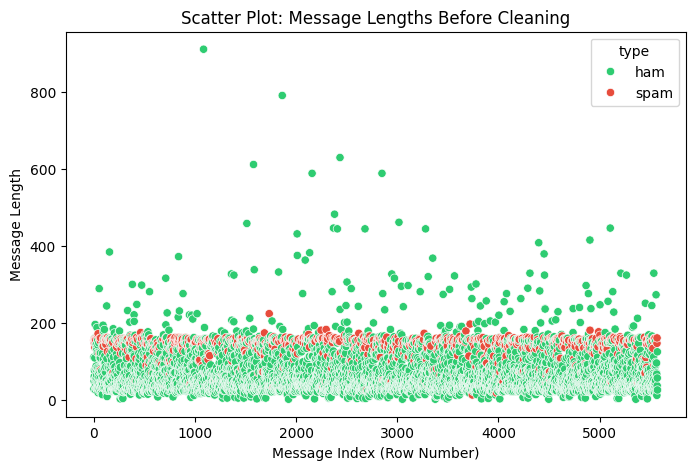

In [10]:
# 2. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=df.index, y='length', hue='type', palette=["#2ecc71", "#e74c3c"])
plt.title("Scatter Plot: Message Lengths Before Cleaning")
plt.xlabel("Message Index (Row Number)")
plt.ylabel("Message Length")
plt.show()

In [11]:
# ==========================================
# 3. DO THE PREPROCESSING (Clean the data)
# ==========================================
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
type      0
text      0
length    0
dtype: int64


In [12]:
# ==========================================
# 3. OUTLIER DETECTION AND REMOVAL (Z-SCORE)
# ==========================================
# First handle any true missing values if they exist
df_clean = df.dropna().copy()

In [13]:
# Count total rows before outlier removal
total_rows_before = len(df_clean)
print(f"Total rows before outlier removal: {total_rows_before}")

Total rows before outlier removal: 5574


In [14]:
# Find outliers using Z-score (> 3 standard deviations)
z_scores = abs(stats.zscore(df_clean['length']))

In [15]:
# Filter clean data
df_clean = df_clean[z_scores < 3]
print(f"Max message length before: {df['length'].max()}")
print(f"Max message length after: {df_clean['length'].max()}")

Max message length before: 910
Max message length after: 257


In [16]:
# Count how many outliers were removed
total_rows_after = len(df_clean)
num_outliers_removed = total_rows_before - total_rows_after
print(f"Total outliers removed: {num_outliers_removed}")
print(f"Total rows after outlier removal: {total_rows_after}")

Total outliers removed: 64
Total rows after outlier removal: 5510


In [17]:
# Reset the index so the row numbers are sequential again
df_clean = df_clean.reset_index(drop=True)

In [18]:
print("\n1. Shape (.shape):")
print(df_clean.shape)


1. Shape (.shape):
(5510, 3)


In [19]:
print("\n2. Summary Statistics (.describe()):")
print(df_clean.describe())


2. Summary Statistics (.describe()):
            length
count  5510.000000
mean     77.220508
std      49.803690
min       2.000000
25%      35.000000
50%      61.000000
75%     120.000000
max     257.000000


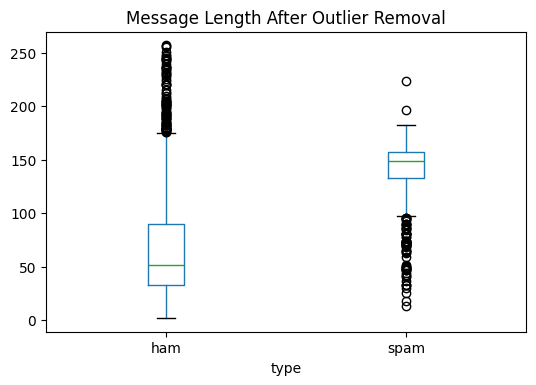

In [20]:
# 1. Boxplot After Outlier Removal
df_clean.boxplot(column='length', by='type', grid=False, figsize=(6,4))
plt.title("Message Length After Outlier Removal")
plt.suptitle("")
plt.show()

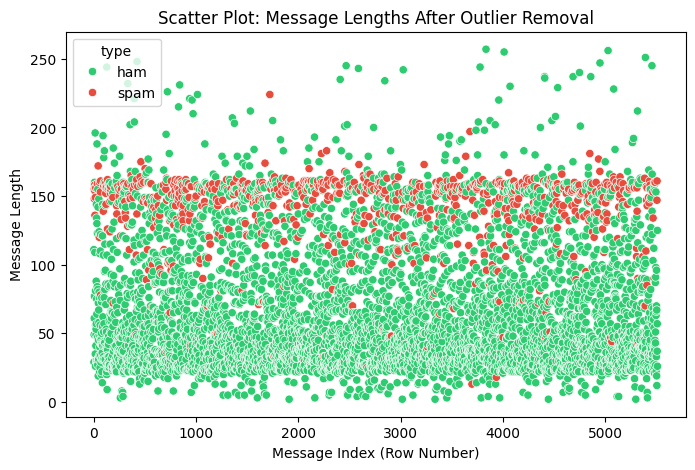

In [21]:
# 2. Scatter Plot After Outlier Removal
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x=df_clean.index, y='length', hue='type', palette=["#2ecc71", "#e74c3c"])
plt.title("Scatter Plot: Message Lengths After Outlier Removal")
plt.xlabel("Message Index (Row Number)")
plt.ylabel("Message Length")
plt.show()

In [22]:
# ==========================================
# 5. STATISTICAL ANALYSIS (Z-TEST)
# ==========================================
print("==========================================")
print("           Z-TEST ANALYSIS")
print("==========================================\n")

spam_lengths = df_clean[df_clean['type'] == 'spam']['length']
ham_lengths = df_clean[df_clean['type'] == 'ham']['length']

z_stat, p_value = ztest(spam_lengths, ham_lengths)

print(f"Z-Statistic: {z_stat:.2f}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("\nConclusion: Because the P-Value is less than 0.05, we reject the null hypothesis.")
    print("This mathematically proves there is a significant difference in length between Spam and Ham messages!")
else:
    print("\nConclusion: There is no significant difference in length between Spam and Ham messages.")

           Z-TEST ANALYSIS

Z-Statistic: 41.94
P-Value: 0.0

Conclusion: Because the P-Value is less than 0.05, we reject the null hypothesis.
This mathematically proves there is a significant difference in length between Spam and Ham messages!


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Convert text messages into numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(df_clean['text'])
y = df_clean['type']

# Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data preparation complete!")

Data preparation complete!


=== Naive Bayes Performance ===
Accuracy   : 98.19%
Error Rate : 1.81%



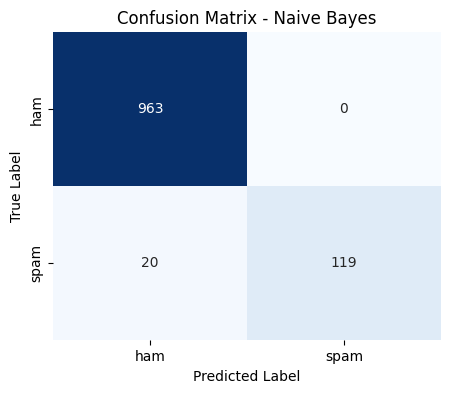

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Calculate metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
err_nb = 1.0 - acc_nb
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("=== Naive Bayes Performance ===")
print(f"Accuracy   : {acc_nb * 100:.2f}%")
print(f"Error Rate : {err_nb * 100:.2f}%\n")

# Individual Confusion Matrix Graph for Naive Bayes
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

=== Logistic Regression Performance ===
Accuracy   : 97.46%
Error Rate : 2.54%



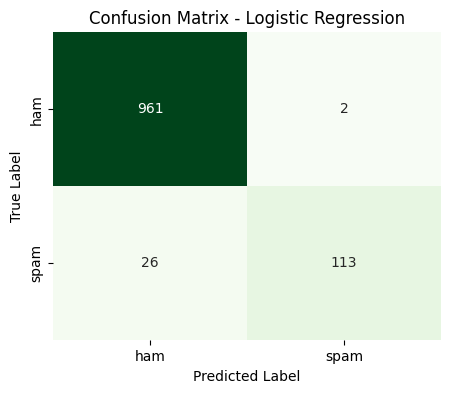

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
err_lr = 1.0 - acc_lr
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("=== Logistic Regression Performance ===")
print(f"Accuracy   : {acc_lr * 100:.2f}%")
print(f"Error Rate : {err_lr * 100:.2f}%\n")

# Individual Confusion Matrix Graph for Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

=== Support Vector Machine (SVM) Performance ===
Accuracy   : 98.46%
Error Rate : 1.54%



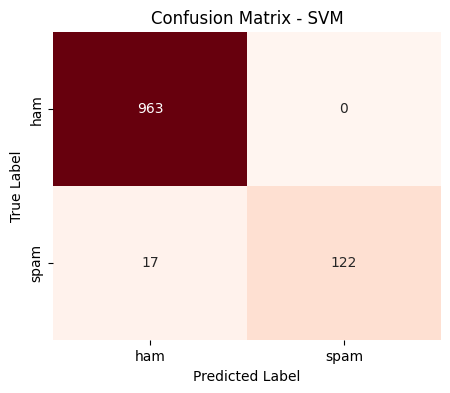

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Calculate metrics
acc_svm = accuracy_score(y_test, y_pred_svm)
err_svm = 1.0 - acc_svm
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("=== Support Vector Machine (SVM) Performance ===")
print(f"Accuracy   : {acc_svm * 100:.2f}%")
print(f"Error Rate : {err_svm * 100:.2f}%\n")

# Individual Confusion Matrix Graph for SVM
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

=== Decision Tree Performance ===
Accuracy   : 96.10%
Error Rate : 3.90%



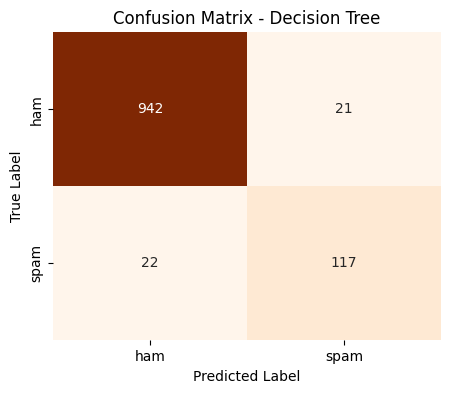

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Calculate metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
err_dt = 1.0 - acc_dt
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("=== Decision Tree Performance ===")
print(f"Accuracy   : {acc_dt * 100:.2f}%")
print(f"Error Rate : {err_dt * 100:.2f}%\n")

# Individual Confusion Matrix Graph for Decision Tree
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

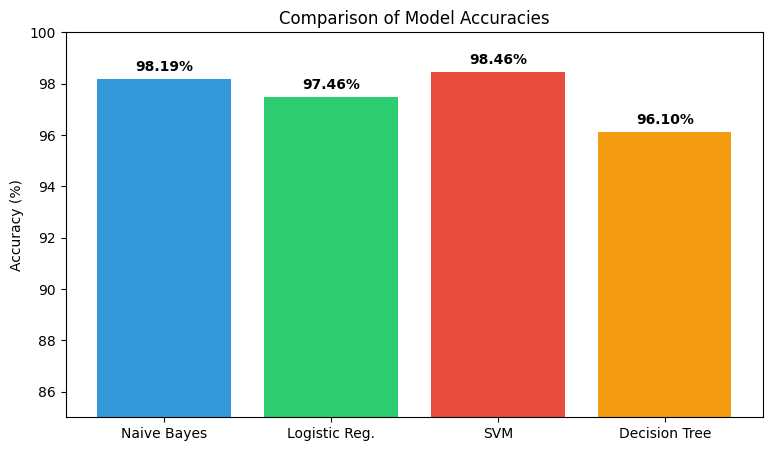

In [28]:
import matplotlib.pyplot as plt

model_names = ["Naive Bayes", "Logistic Reg.", "SVM", "Decision Tree"]
accuracies = [acc_nb * 100, acc_lr * 100, acc_svm * 100, acc_dt * 100]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accuracies, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title("Comparison of Model Accuracies")
plt.ylabel("Accuracy (%)")
plt.ylim(85, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.show()